Enter Excel dataset path: buys_computer.xlsx

BUILDING ID3 DECISION TREE


ITERATION 1
Current Node : ROOT

CURRENT DATASET USED IN THIS ITERATION:
------------------------------------------------
    Age Income Student Credit_Rating Buys_Computer
   <=30   High      No          Fair            No
   <=30   High      No     Excellent            No
31...40   High      No          Fair           Yes
    >40 Medium      No          Fair           Yes
    >40    Low     Yes          Fair           Yes
    >40    Low     Yes     Excellent            No
31...40    Low     Yes     Excellent           Yes
   <=30 Medium      No          Fair            No
   <=30    Low     Yes          Fair           Yes
    >40 Medium     Yes          Fair           Yes
   <=30 Medium     Yes     Excellent           Yes
31...40 Medium      No     Excellent           Yes
31...40   High     Yes          Fair           Yes
    >40 Medium      No     Excellent            No
--------------------------------------

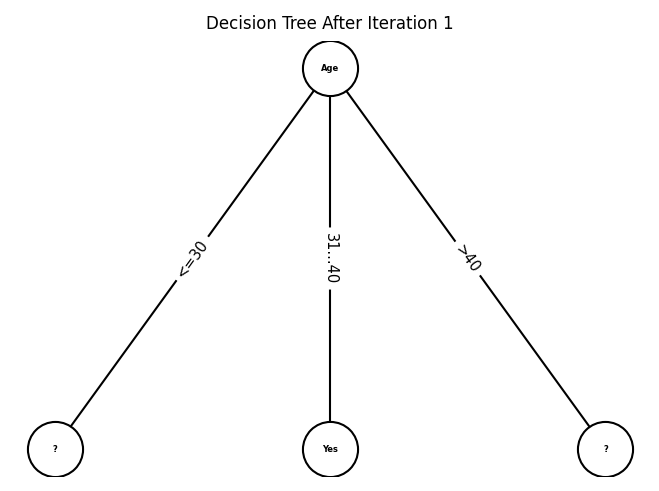



ITERATION 2
Current Node : Age = <=30

CURRENT DATASET USED IN THIS ITERATION:
------------------------------------------------
 Age Income Student Credit_Rating Buys_Computer
<=30   High      No          Fair            No
<=30   High      No     Excellent            No
<=30 Medium      No          Fair            No
<=30    Low     Yes          Fair           Yes
<=30 Medium     Yes     Excellent           Yes
------------------------------------------------

Entropy of Dataset = 0.971

Attribute: Income
Entropy(High) = 0.0
Entropy(Medium) = 1.0
Entropy(Low) = 0.0
Gain(Income) = 0.571

Attribute: Student
Entropy(No) = 0.0
Entropy(Yes) = 0.0
Gain(Student) = 0.971

Attribute: Credit_Rating
Entropy(Fair) = 0.9183
Entropy(Excellent) = 1.0
Gain(Credit_Rating) = 0.02

--------------------------------------------
Best Attribute Selected = Student
--------------------------------------------

Tree Rules after iteration 2

IF Age = <=30 THEN:
    IF Student = No THEN Buys_Computer = No
    

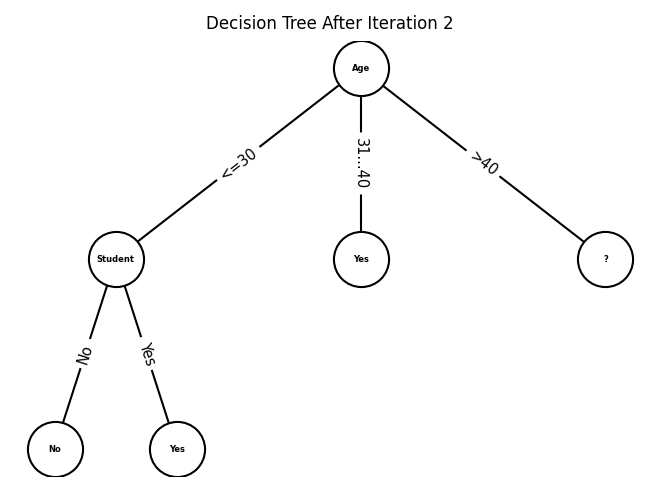



ITERATION 3
Current Node : Age = >40

CURRENT DATASET USED IN THIS ITERATION:
------------------------------------------------
Age Income Student Credit_Rating Buys_Computer
>40 Medium      No          Fair           Yes
>40    Low     Yes          Fair           Yes
>40    Low     Yes     Excellent            No
>40 Medium     Yes          Fair           Yes
>40 Medium      No     Excellent            No
------------------------------------------------

Entropy of Dataset = 0.971

Attribute: Income
Entropy(Medium) = 0.9183
Entropy(Low) = 1.0
Gain(Income) = 0.02

Attribute: Student
Entropy(No) = 1.0
Entropy(Yes) = 0.9183
Gain(Student) = 0.02

Attribute: Credit_Rating
Entropy(Fair) = 0.0
Entropy(Excellent) = 0.0
Gain(Credit_Rating) = 0.971

--------------------------------------------
Best Attribute Selected = Credit_Rating
--------------------------------------------

Tree Rules after iteration 3

IF Age = <=30 THEN:
    IF Student = No THEN Buys_Computer = No
    IF Student = Yes TH

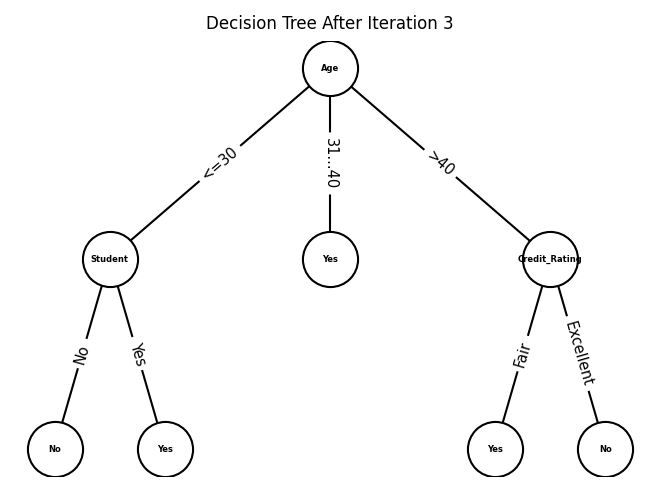



FINAL DECISION TREE



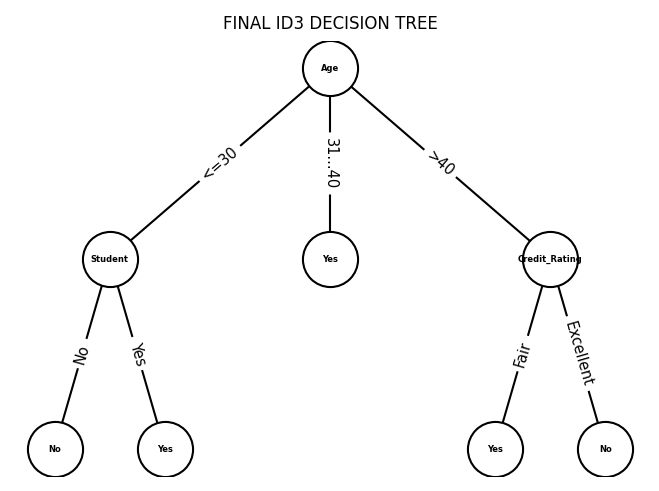



ENTER VALUES TO CLASSIFY NEW SAMPLE

Enter value for Age:<=30
Enter value for Income:low
Enter value for Student:yes
Enter value for Credit_Rating:fair

CLASSIFICATION RESULT
New Sample: {'Age': '<=30', 'Income': 'low', 'Student': 'yes', 'Credit_Rating': 'fair'}
Predicted Class: Yes


In [ ]:
import pandas as pd
import math
import networkx as nx
import matplotlib.pyplot as plt

# LOAD DATASET
path = input("Enter Excel dataset path: ")
df = pd.read_excel(path)

# CLEAN DATASET
for col in df.columns:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.capitalize()
    )

# REMOVE FIRST COLUMN (ID COLUMN)
id_column = df.columns[0]
df = df.drop(columns=[id_column])

# GLOBAL VARIABLES
iteration = 1
current_tree = {}

# ENTROPY FUNCTION
def entropy(data, target_column):
    target_values = data[target_column].value_counts()
    total_entropy = 0
    for count in target_values:
        probability = count / len(data)
        total_entropy -= probability * math.log2(probability)
    return total_entropy


# INFORMATION GAIN FUNCTION
def information_gain(data, attribute, target_column):
    total_entropy = entropy(data, target_column)
    print(f"\nAttribute: {attribute}")
    weighted_entropy = 0
    unique_values = data[attribute].unique()
    for value in unique_values:
        subset = data[data[attribute] == value]
        subset_entropy = entropy(subset, target_column)
        weight = len(subset) / len(data)
        weighted_entropy += weight * subset_entropy
        print(f"Entropy({value}) = {round(subset_entropy, 4)}")
    gain = total_entropy - weighted_entropy
    print(f"Gain({attribute}) = {round(gain, 4)}")
    return gain


# DISPLAY RULES
def display_rules(tree, target_column, indent=""):
    if not isinstance(tree, dict):
        return

    root = next(iter(tree))
    for value, subtree in tree[root].items():
        if isinstance(subtree, dict):
            print(f"{indent}IF {root} = {value} THEN:")
            display_rules(subtree, target_column, indent + "    ")
        elif subtree == "?":
            print(f"{indent}IF {root} = {value} THEN ?")
        else:
            print(
                f"{indent}IF {root} = {value} "
                f"THEN {target_column} = {subtree}"
            )


# TREE DRAWING FUNCTIONS
def add_edges(graph, tree, parent=None, edge_label=""):
    if not isinstance(tree, dict):
        return

    root = next(iter(tree))
    root_id = f"{root}_{id(tree)}"
    graph.add_node(root_id, label=root)

    if parent is not None:
        graph.add_edge(parent, root_id, label=edge_label)

    for value, subtree in tree[root].items():
        if not isinstance(subtree, dict):
            leaf_id = f"{subtree}_{value}_{id(subtree)}"
            graph.add_node(leaf_id, label=subtree)
            graph.add_edge(root_id, leaf_id, label=value)
        else:
            add_edges(graph, subtree, root_id, str(value))


# TREE POSITIONING
def hierarchy_pos(graph, root=None, width=1.0,
                  vert_gap=0.2, vert_loc=0,
                  xcenter=0.5):

    if len(graph.nodes) == 0:
        return {}

    if root is None:
        root = list(graph.nodes)[0]

    def _hierarchy_pos(graph, root, width=1.0,
                       vert_gap=0.2,
                       vert_loc=0,
                       xcenter=0.5,
                       pos=None,
                       visited=None):

        if visited is None:
            visited = set()
        visited.add(root)

        if pos is None:
            pos = {root: (xcenter, vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)

        children = [
            n for n in graph.neighbors(root)
            if n not in visited
        ]

        if len(children) != 0:
            dx = width / len(children)
            nextx = xcenter - width / 2 - dx / 2
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(
                    graph,
                    child,
                    width=dx,
                    vert_gap=vert_gap,
                    vert_loc=vert_loc - vert_gap,
                    xcenter=nextx,
                    pos=pos,
                    visited=visited
                )
        return pos
    return _hierarchy_pos(
        graph,
        root,
        width,
        vert_gap,
        vert_loc,
        xcenter
    )


# DRAW FINAL TREE
def draw_tree(tree, title):

    graph = nx.DiGraph()
    add_edges(graph, tree)
    plt.figure(figsize=(4.2, 2.9), dpi=150)
    root = list(graph.nodes)[0]
    pos = hierarchy_pos(
        graph,
        root,
        width=0.20,
        vert_gap=0.035,
        xcenter=0.5
    )

    labels = nx.get_node_attributes(graph, 'label')
    edge_labels = nx.get_edge_attributes(graph, 'label')

    nx.draw(
        graph,
        pos,
        labels=labels,
        with_labels=True,
        node_size=700,
        node_color='white',
        edgecolors='black',
        linewidths=1,
        font_size=4,
        font_weight='bold',
        arrows=False
    )
    nx.draw_networkx_edge_labels(
        graph,
        pos,
        edge_labels=edge_labels,
        font_size=7
    )
    plt.title(title, fontsize=8)
    plt.axis('off')
    plt.margins(0.02)
    plt.show()


# ID3 ALGORITHM
def id3(data, original_data,
        features, target_column,
        parent_node="ROOT"):

    global iteration
    global current_tree

    # Pure class
    if len(data[target_column].unique()) == 1:
        return data[target_column].iloc[0]

    # Empty dataset
    if len(data) == 0:
        return original_data[target_column].mode()[0]

    # No features left
    if len(features) == 0:
        return data[target_column].mode()[0]

    print("\n\n====================================================")
    print(f"ITERATION {iteration}")
    print("====================================================")
    print(f"Current Node : {parent_node}")

    print("\nCURRENT DATASET USED IN THIS ITERATION:")
    print("------------------------------------------------")
    print(data.to_string(index=False))
    print("------------------------------------------------")

    dataset_entropy = entropy(data, target_column)
    print(f"\nEntropy of Dataset = {round(dataset_entropy, 4)}")
    gains = []

    for feature in features:
        gain = information_gain(
            data,
            feature,
            target_column
        )
        gains.append(gain)

    best_feature_index = gains.index(max(gains))
    best_feature = features[best_feature_index]
    print("\n--------------------------------------------")
    print(f"Best Attribute Selected = {best_feature}")
    print("--------------------------------------------")

    tree = {best_feature: {}}
    remaining_features = [
        feature for feature in features
        if feature != best_feature
    ]
    unique_values = data[best_feature].unique()


    for value in unique_values:
        subset = data[data[best_feature] == value]

        if len(subset[target_column].unique()) == 1:

            tree[best_feature][value] = (
                subset[target_column].iloc[0]
            )
        else:
            tree[best_feature][value] = "?"

    if iteration == 1:
        current_tree = tree

    else:
        def replace_question(node):
            if not isinstance(node, dict):
                return False
            root = next(iter(node))
            for key in node[root]:
                if node[root][key] == "?":
                    node[root][key] = tree
                    return True
                elif isinstance(node[root][key], dict):
                    done = replace_question(node[root][key])
                    if done:
                        return True
            return False
        replace_question(current_tree)

    print(f"\nTree Rules after iteration {iteration}\n")
    display_rules(current_tree, target_column)

    draw_tree(
        current_tree,
        f"Decision Tree After Iteration {iteration}"
    )

    # print("\n------------------------------------------------")
    iteration += 1

    for value in unique_values:
        subset = data[data[best_feature] == value]
        # Skip pure branches
        if len(subset[target_column].unique()) == 1:
            continue
        subtree = id3(
        subset,
        original_data,
        remaining_features,
        target_column,
        parent_node=f"{best_feature} = {value}"
        )
        tree[best_feature][value] = subtree
    return tree


# PREDICTION FUNCTION
def predict(tree, sample):
    if not isinstance(tree, dict):
        return tree
    root = next(iter(tree))
    value = str(sample[root]).strip().capitalize()
    subtree = tree[root].get(value)
    if subtree is None:
        return "Unknown"
    return predict(subtree, sample)


# BUILD TREE
target_column = df.columns[-1]
features = list(df.columns[:-1])

print("\n====================================================")
print("BUILDING ID3 DECISION TREE")
print("====================================================")
final_tree = id3(
    df,
    df,
    features,
    target_column,
    parent_node="ROOT"
)

# FINAL DECISION TREE
print("\n\n====================================================")
print("FINAL DECISION TREE")
print("====================================================\n")
draw_tree(
    final_tree,
    "FINAL ID3 DECISION TREE"
)

# CLASSIFY NEW SAMPLE
print("\n\n====================================================")
print("ENTER VALUES TO CLASSIFY NEW SAMPLE")
print("====================================================\n")

new_sample = {}
for feature in features:
    value = input(f"Enter value for {feature}:").strip()
    new_sample[feature] = value
prediction = predict(final_tree, new_sample)

print("\n====================================================")
print("CLASSIFICATION RESULT")
print("====================================================")
print("New Sample:", new_sample)
print("Predicted Class:", prediction)